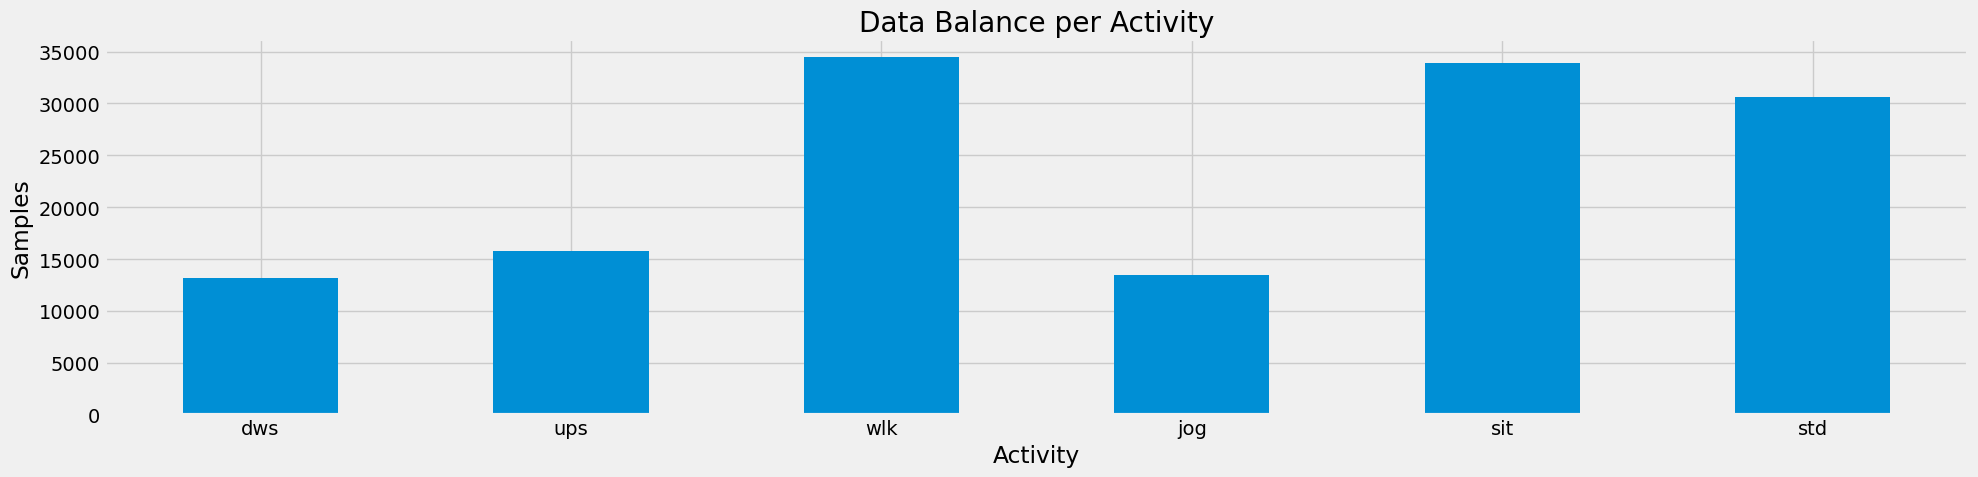

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Setup and Load Data

plt.style.use("fivethirtyeight")
plt.rcParams["figure.figsize"] = (20, 5)
plt.rcParams["figure.dpi"] = 100

df = pd.read_pickle("../../data/processed/data_processed.pkl")
os.makedirs("../../reports/figures/", exist_ok=True)

LABEL_NAME = {
    0: "dws",
    1: "ups",
    2: "wlk",
    3: "jog",
    4: "sit",
    5: "std"
}

# 2. Data Balance (a)

balance = df["label"].value_counts().sort_index()

plt.figure()
balance.plot(kind="bar")
plt.xticks(balance.index, [LABEL_NAME[l] for l in balance.index])
plt.title("Data Balance per Activity")
plt.xlabel("Activity")
plt.xticks(rotation=0)
plt.ylabel("Samples")
plt.tight_layout()
plt.show()

### Phân bố dữ liệu và nguy cơ mất cân bằng lớp

Phân bố dữ liệu giữa các hoạt động **không đồng đều**. Trong đó:

- **wlk** và **sit** chiếm số lượng mẫu **lớn nhất**
- **std** và **ups** có số lượng mẫu ở **mức trung bình**
- **dws** và **jog** có số lượng mẫu **ít nhất**

Do các lớp có nhiều mẫu thường được mô hình học **tốt hơn**, nên tồn tại rủi ro mô hình bị **thiên vị (class bias)**. Cụ thể, mô hình có xu hướng ưu tiên dự đoán các hoạt động phổ biến như **wlk**, trong khi hiệu năng đối với các hoạt động có ít dữ liệu như **dws** và **jog** có thể **kém hơn**, dễ bị **dự đoán sai hoặc bỏ sót**.

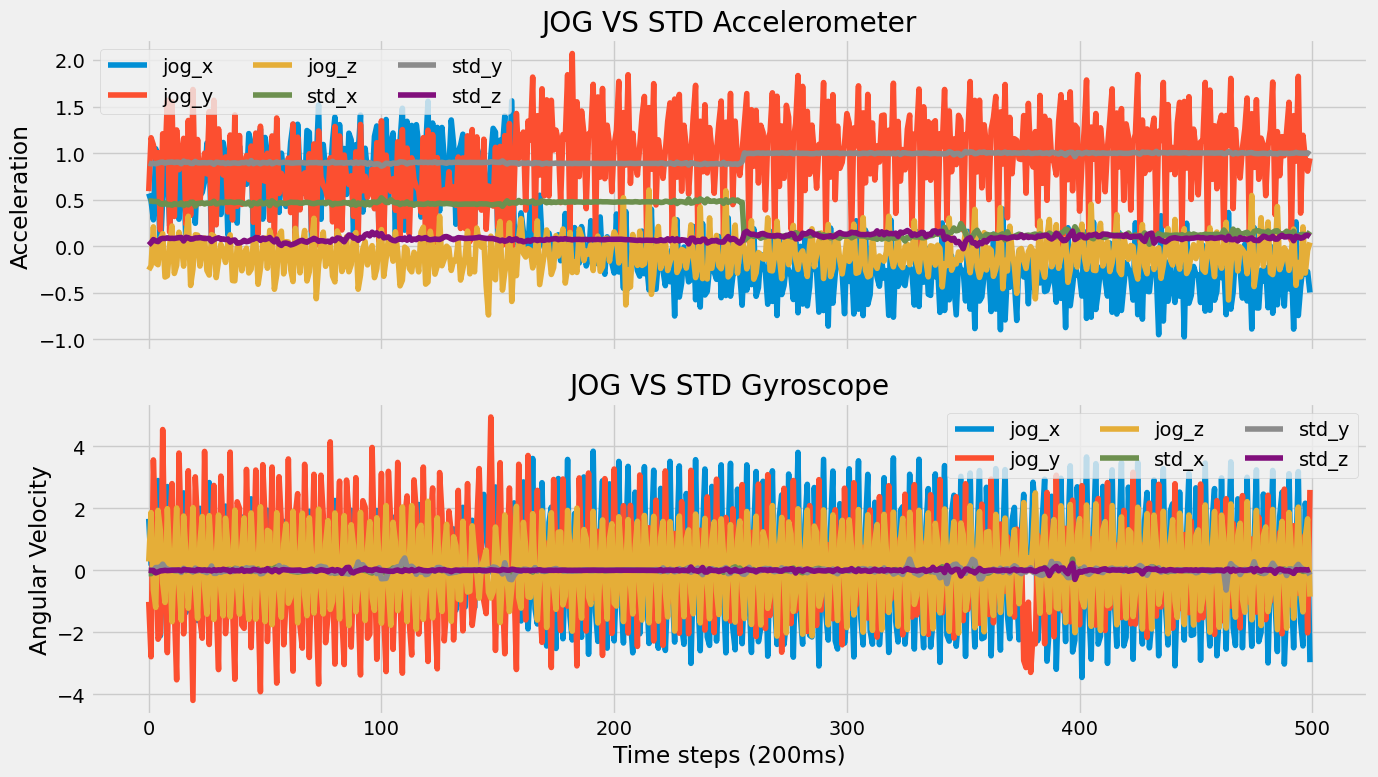

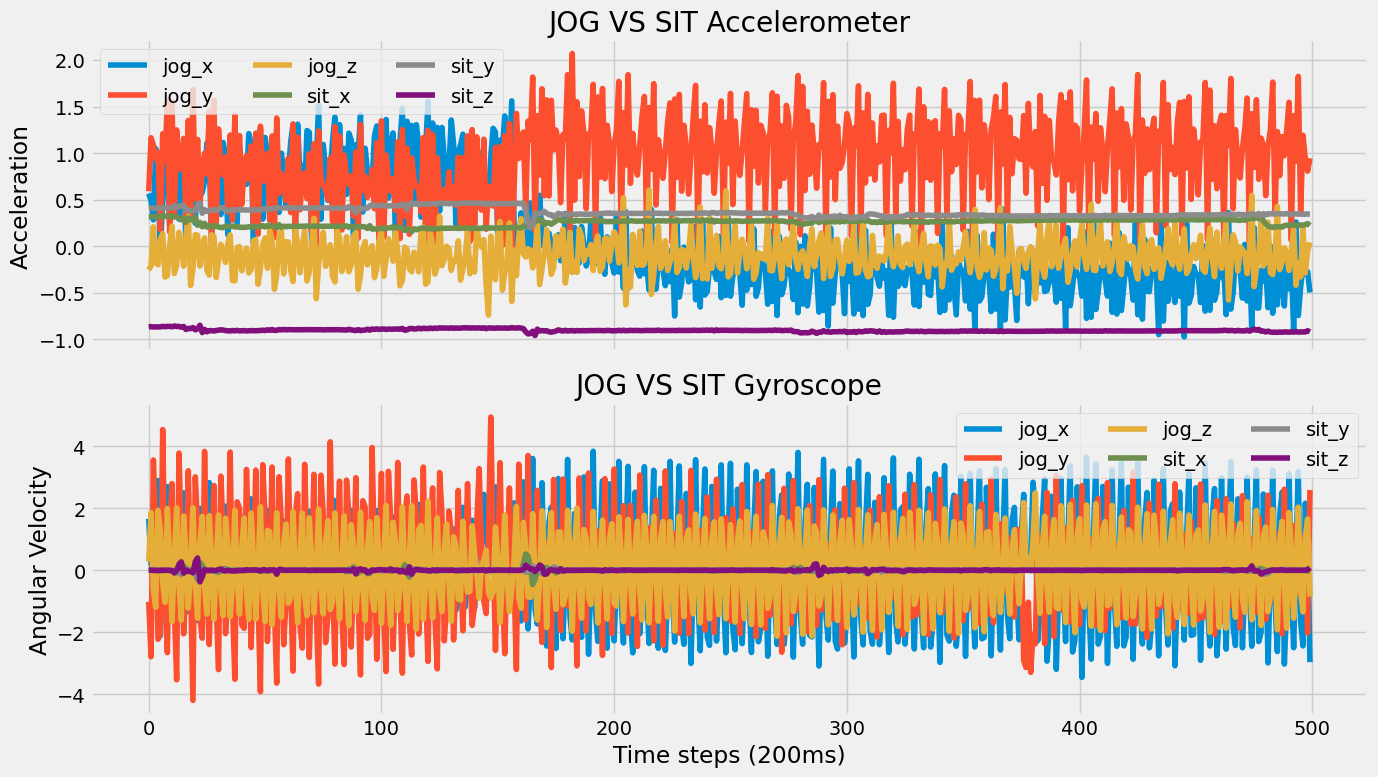

In [2]:
# 3. Compare multiple activities on the same plot (b)

def plot_signals(
    df,
    labels,
    acc_cols=["acc_x", "acc_y", "acc_z"],
    gyr_cols=["gyr_x", "gyr_y", "gyr_z"],
    n_samples=500,
    title=""
):
    fig, axes = plt.subplots(nrows=2, figsize=(14, 8), sharex=True)

    user = df[df["label"].isin(labels)]["user_id"].iloc[0]

    for label in labels:
        subset = (
            df[(df["label"] == label) & (df["user_id"] == user)]
            .head(n_samples)
            .reset_index(drop=True)
        )
        for col in acc_cols:
            axes[0].plot(subset[col], label=f"{LABEL_NAME[label]}_{col[-1]}")

    axes[0].set_title(f"{title} Accelerometer")
    axes[0].set_ylabel("Acceleration")
    axes[0].legend(ncol=3)

    for label in labels:
        subset = (
            df[(df["label"] == label) & (df["user_id"] == user)]
            .head(n_samples)
            .reset_index(drop=True)
        )
        for col in gyr_cols:
            axes[1].plot(subset[col], label=f"{LABEL_NAME[label]}_{col[-1]}")

    axes[1].set_title(f"{title} Gyroscope")
    axes[1].set_xlabel("Time steps (200ms)")
    axes[1].set_ylabel("Angular Velocity")
    axes[1].legend(ncol=3)

    plt.tight_layout()
    plt.show()

plot_signals(df, [3, 5], title="JOG VS STD")
plot_signals(df, [3, 4], title="JOG VS SIT")

**JOG VS STD/SIT:**

- **JOG**: Gia tốc trên cả 3 trục rất lớn và dao động liên tục, trong đó trục *y* có biên độ lớn nhất  
- **STD/SIT**: Gia tốc ổn định và dao động rất nhỏ  

→ **Acc** phân biệt rõ **JOG** và **STD/SIT**  

→ Tương tự, **gyr** cũng phân biệt rõ **JOG** và **STD**  
(gyr đặc biệt hiệu quả với những hoạt động có sự dao động gia tốc gần giống nhau, ví dụ như **WLK VS UPS/DWS**, **SIT VS STD** → hãy thử thêm bằng cách gọi hàm trên nếu cần!)


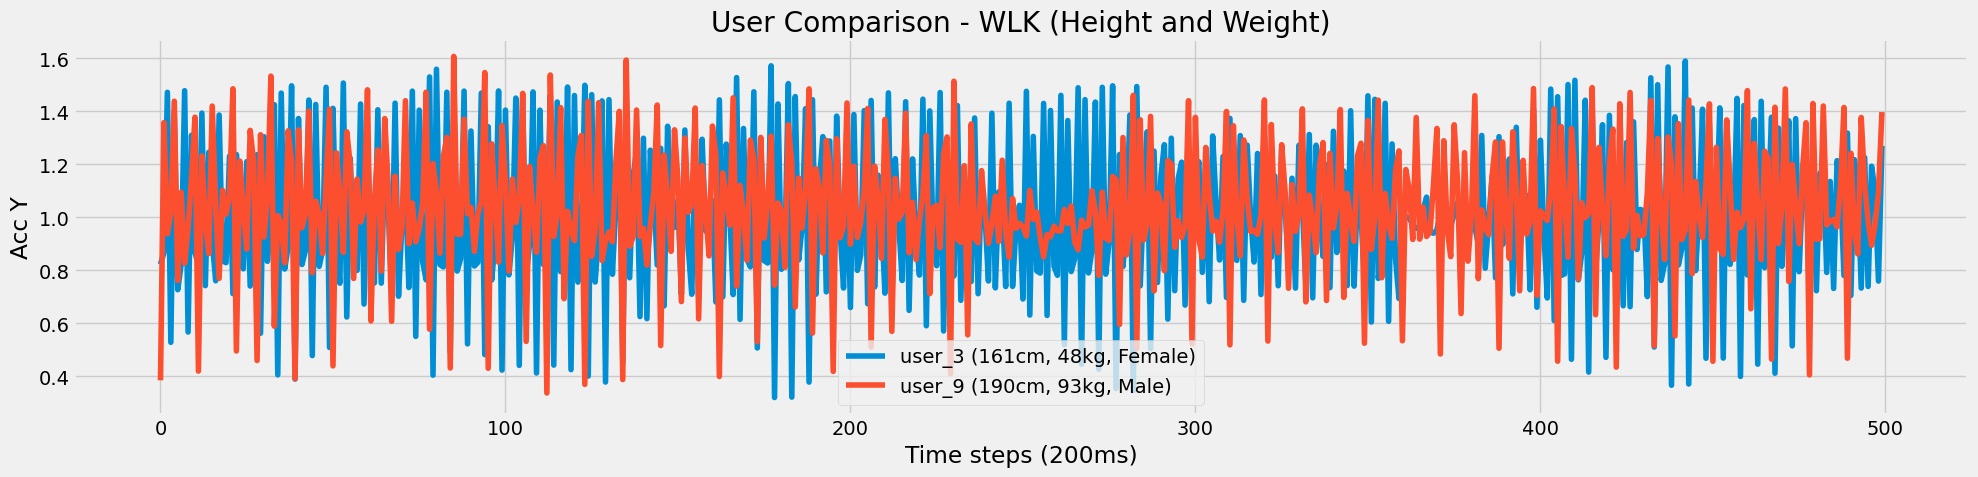

In [3]:
# 4. Compare multiple participants in an activity (c)
label = 2

gender_conv = {1: "Male", 0: "Female"}

user_info = (
    df[df["label"] == label]
    .groupby("user_id")[["height", "weight", "gender"]]
    .first()
    .sort_values("height")
)

short_user = user_info.iloc[0]
tall_user = user_info.iloc[-1]

plt.figure()

for u, info in zip(
    [short_user.name, tall_user.name],
    [short_user, tall_user]
):
    u_df = (
        df[(df["label"] == label) & (df["user_id"] == u)]
        .head(500)
        .reset_index(drop=True)
    )
    
    gender = gender_conv.get(info.gender, "Unknown")
    plt.plot(
        u_df["acc_y"],
        label=f"user_{u} ({info.height}cm, {info.weight}kg, {gender})"
    )

plt.title("User Comparison - WLK (Height and Weight)")
plt.xlabel("Time steps (200ms)")
plt.ylabel("Acc Y")
plt.legend()
plt.tight_layout()
plt.show()


Biểu đồ so sánh tín hiệu gia tốc theo trục **Y** của hai người dùng có sự khác biệt về **chiều cao / cân nặng / giới tính (nam/nữ)** với cùng một hoạt động **WLK**. Ta thấy có sự khác biệt trong dao động của hai người, điều này là do đặc điểm cá nhân của người dùng về **chiều cao, cân nặng và giới tính**.

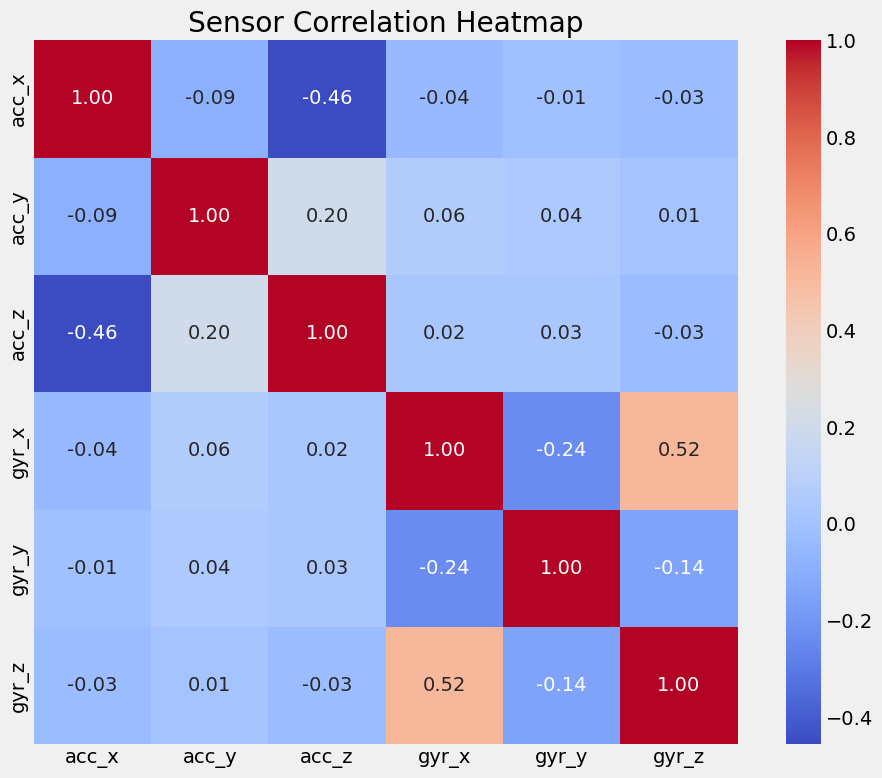

In [4]:
# 5. Correlation

corr_df = df[["acc_x", "acc_y", "acc_z", "gyr_x", "gyr_y", "gyr_z"]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Sensor Correlation Heatmap")
plt.tight_layout()
plt.show()

## Correlation Heatmap

- Correlation heatmap cho biết mức độ các tín hiệu cảm biến thay đổi **giống nhau** hoặc **ngược nhau**
- Luôn **đối xứng qua đường chéo**, ví dụ:  
  `corr(acc_x, acc_y) = corr(acc_y, acc_x)`
- Trên **đường chéo**, sensor được so với chính nó nên giá trị luôn bằng **1**
- Hệ số tương quan: `corr ∈ [-1, 1]`
+ corr = 1: tương quan hoàn hảo cùng chiều
+ corr = -1: tương quan hoàn hảo ngược chiều
+ corr ≈ 0: gần như không có tương quan tuyến tính

### Ý nghĩa giá trị tương quan
- **Giá trị dương (+)**: một tín hiệu tăng thì tín hiệu còn lại cũng tăng  
- **Giá trị âm (−)**: một tín hiệu tăng thì tín hiệu còn lại giảm (mối quan hệ bù trừ)  
- **Gần hoặc bằng 0**: hai tín hiệu hầu như không liên quan đến nhau  

### Ví dụ
- **gyr_x ↔ gyr_z = 0.52** *(dương, cao nhất)*  
  → Khi quay quanh trục *x* thì cũng có xu hướng quay quanh trục *z*  
  → Chuyển động xoay có thể diễn ra đồng thời trên nhiều trục  

- **acc_x ↔ acc_z = −0.46** *(âm, thấp nhất)*  
  → Khi gia tốc theo trục *x* tăng thì gia tốc theo trục *z* giảm  
  → Hai trục có mối quan hệ **bù trừ** nhằm giữ sự ổn định trong chuyển động  

**Ví dụ minh họa:**  
Khi thực hiện hoạt động đi bộ (WLK), tại những thời điểm gia tốc theo hướng chuyển động chính (chạy thẳng) tăng lên thì gia tốc theo các hướng khác (chạy sang trái/phải) có xu hướng giảm, qua đó giúp cơ thể duy trì sự ổn định khi di chuyển.

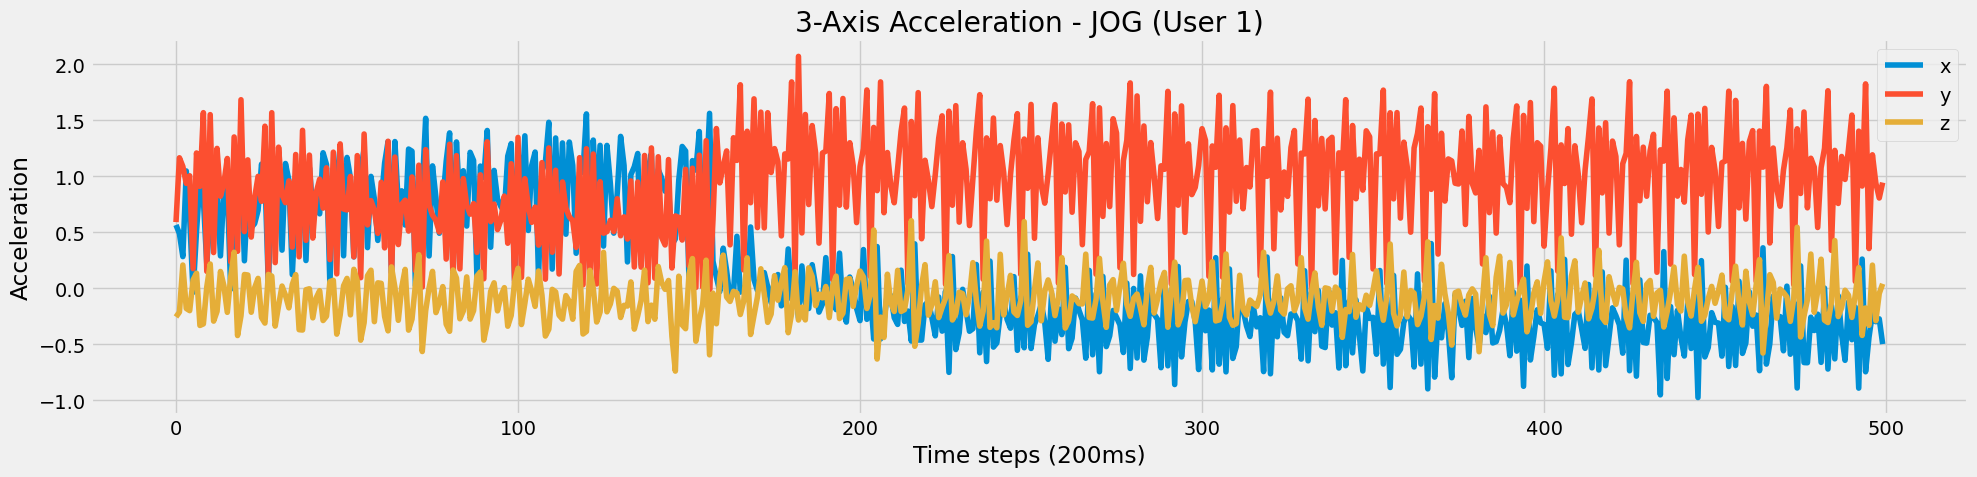

In [5]:
# 6. Time-series plot
label = 3
user = df[df["label"] == label]["user_id"].iloc[0]

multi_axis_df = (
    df[(df["label"] == label) & (df["user_id"] == user)]
    .head(500)
    .reset_index(drop=True)
)

plt.figure()
plt.plot(multi_axis_df["acc_x"], label="x")
plt.plot(multi_axis_df["acc_y"], label="y")
plt.plot(multi_axis_df["acc_z"], label="z")
plt.title(f"3-Axis Acceleration - {LABEL_NAME[label].upper()} (User {user})")
plt.xlabel("Time steps (200ms)")
plt.ylabel("Acceleration")
plt.legend()
plt.tight_layout()
plt.show()

Gia tốc dao động liên tục theo thời gian trên cả **3 trục**, trong đó **trục y** chiếm ưu thế nhất. Điều đó cho thấy **trục y** là hướng chuyển động chính của cơ thể khi thực hiện hành động này.

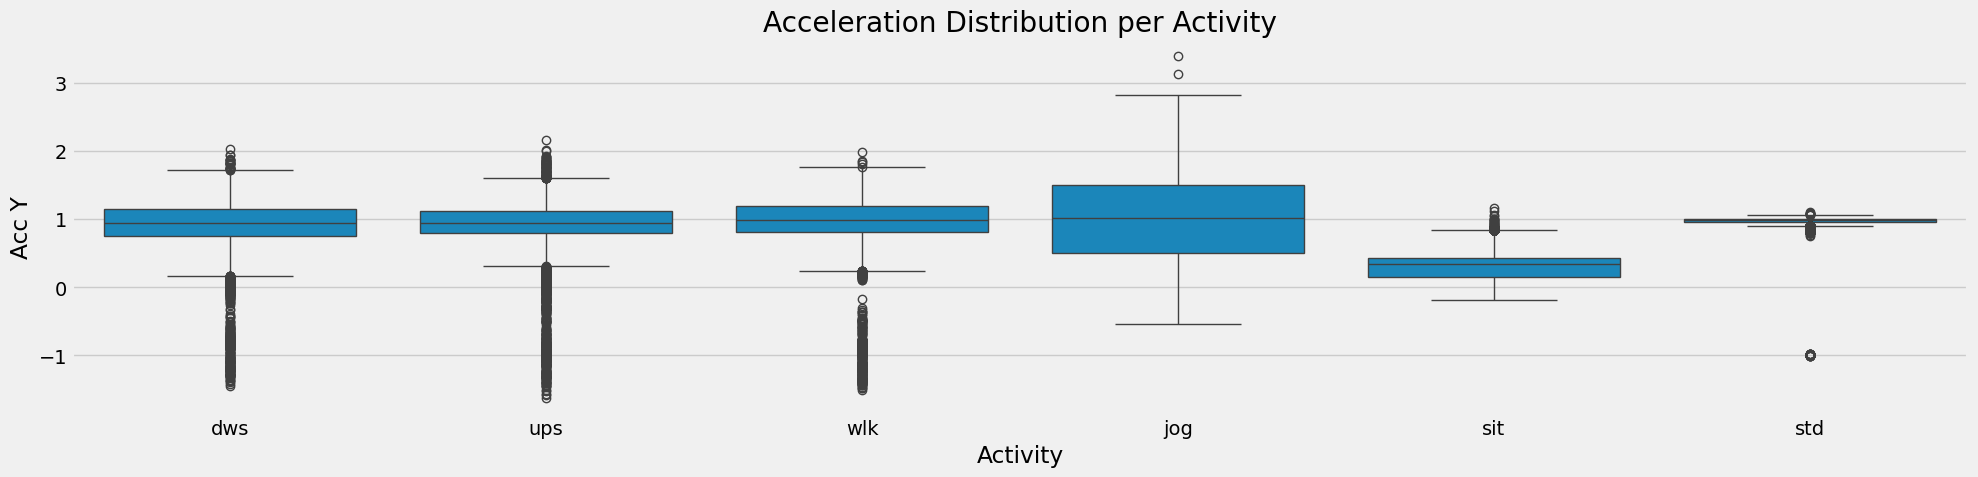

In [6]:
# 7. Boxplot

plt.figure()
sns.boxplot(x="label", y="acc_y", data=df)
plt.xticks(df["label"].unique(), [LABEL_NAME[l] for l in df["label"].unique()])
plt.title("Acceleration Distribution per Activity")
plt.xlabel("Activity")
plt.ylabel("Acc Y")
plt.tight_layout()
plt.show()

**Median(Trung vị - là đường nằm giữa hình hộp):**  
jog > wlk > dws ≈ ups > std > sit  

**IQR(Độ rộng hộp):**  
jog > wlk > ups ≈ dws > sit > std  

→ **Median** càng cao thì gia tốc càng mạnh, càng thấp thì mức độ chuyển động càng ít  
→ **IQR** càng rộng thì dữ liệu dao động càng nhiều, càng hẹp thì tín hiệu càng ổn định  

**Outlier:**  
- **dws**: (- nhiều / + ít)  
- **ups**: (- nhiều nhất / + ít)  
- **wlk**: (- vừa phải / + ít)  
- **jog**: (+ nhiều)  
- **sit**: (+ ít)  
- **std**: (- cực ít ⇔ gần như không có)  

**Trong đó:**  

**Outlier (+)**  
→ tăng tốc mạnh, bật người, tiếp đất  

**Outlier (-)**  
→ giảm tốc đột ngột, đổi hướng, hạ chân

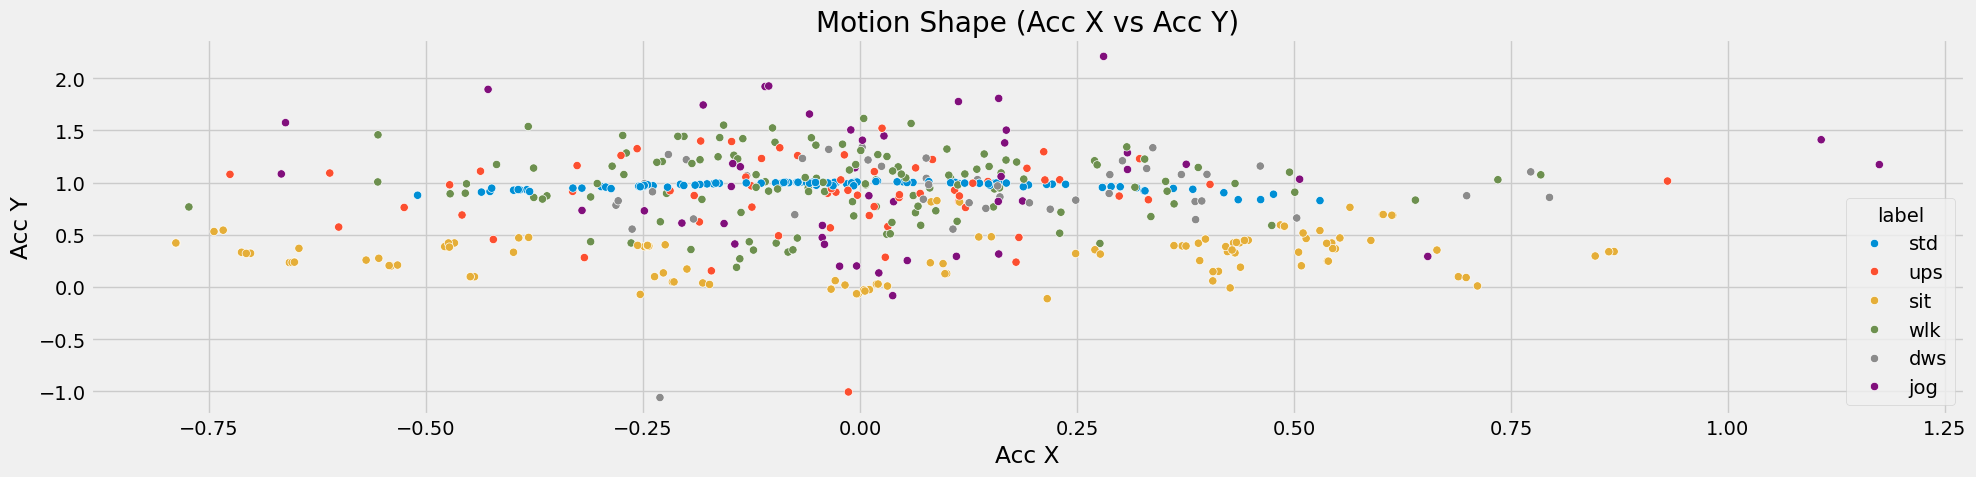

In [7]:
# 8. Scatter plot
scatter_df = df.sample(500, random_state=42)

plt.figure()
sns.scatterplot(
    x="acc_x",
    y="acc_y",
    hue=scatter_df["label"].map(LABEL_NAME),
    data = scatter_df,
    legend="full"
)
plt.title("Motion Shape (Acc X vs Acc Y)")
plt.xlabel("Acc X")
plt.ylabel("Acc Y")
plt.tight_layout()
plt.show()

- **JOG, WLK, UPS và DWS** có độ phân tán lớn, cho thấy gia tốc thay đổi mạnh và liên tục trong suốt quá trình thực hiện hành động. Ngược lại, **SIT** và **STD** có xu hướng tập trung xung quanh một số vùng và tạo thành các cụm hẹp, thể hiện sự ổn định trong chuyển động.  

- Mặc dù đã giảm số lượng mẫu xuống khá thấp (ban đầu là **5000**) nhằm hạn chế hiện tượng *overplotting*, sự chồng chéo giữa các điểm dữ liệu vẫn xảy ra. Điều này cho thấy **acc_x** và **acc_y** chưa đủ để phân biệt rõ bốn hành động **JOG, WLK, UPS, DWS** → cần cân nhắc bổ sung **acc_z** và áp dụng **windowing**.